## GREMLIN_pytorch

This is a bare minimum version of GREMLIN (no gap removal, etc), intended for educational/demo purposes.  For the full version see [GREMLIN_TF_v2.1](https://colab.research.google.com/github/sokrypton/GREMLIN_CPP/blob/master/GREMLIN_TF.ipynb)

In [1]:
# ------------------------------------------------------------
# "THE BEERWARE LICENSE" (Revision 42):
# <so@g.harvard.edu> and <pkk382@g.harvard.edu> wrote this code.
# As long as you retain this notice, you can do whatever you want
# with this stuff. If we meet someday, and you think this stuff
# is worth it, you can buy us a beer in return.
# --Sergey Ovchinnikov and Peter Koo
# ------------------------------------------------------------

###reimplemented with pytorch by haobo wang, 20190323
# "THE APPLE CIDER LICENSE" :
# As long as you retain this notice, you can do whatever you want
# with this stuff. If we meet someday, and you think this stuff
# is worth it, you can buy me an apple cider in return.

## Load some libraries

In [2]:
import numpy as np
import matplotlib.pylab as plt
import torch
import torch.nn.functional as F
import torch.nn.modules as modules
from torch.autograd import Variable
from torch import optim

## Convert FASTA to MSA np.array()

In [3]:
def parse_fasta(filename):
  '''function to parse fasta file'''
  header = []
  sequence = []
  lines = open(filename, "r")
  for line in lines:
    line = line.rstrip()
    if line[0] == ">":
      header.append(line[1:])
      sequence.append([])
    else:
      sequence[-1].append(line)
  lines.close()
  sequence = [''.join(seq) for seq in sequence]
  return np.array(header), np.array(sequence)

def one_hot(msa,states):
  one = np.eye(states)
  return one[msa]

def mk_msa(seqs):
  '''one hot encode msa'''

  ################
  alphabet = "ARNDCQEGHILKMFPSTWYV-"
  states = len(alphabet)
  a2n = {}
  for a,n in zip(alphabet,range(states)):
    a2n[a] = n

  def aa2num(aa):
    '''convert aa into num'''
    if aa in a2n: return a2n[aa]
    else: return a2n['-']
  ################

  msa = []
  for seq in seqs:
    msa.append([aa2num(aa) for aa in seq])
  msa_ori = np.array(msa)
  return msa_ori, one_hot(msa_ori,states)

In [4]:
import pandas as pd

### AA_genotypes vs median brightness

In [5]:
df = pd.read_csv("amino_acid_genotypes_to_brightness.tsv", sep="\t")

In [6]:
print(len(df))
df_with_std = df[~df['std'].isna()]
print(len(df_with_std))
print(f"Only {len(df_with_std)} of the data has std out of {len(df)}")


54025
1697
Only 1697 of the data has std out of 54025


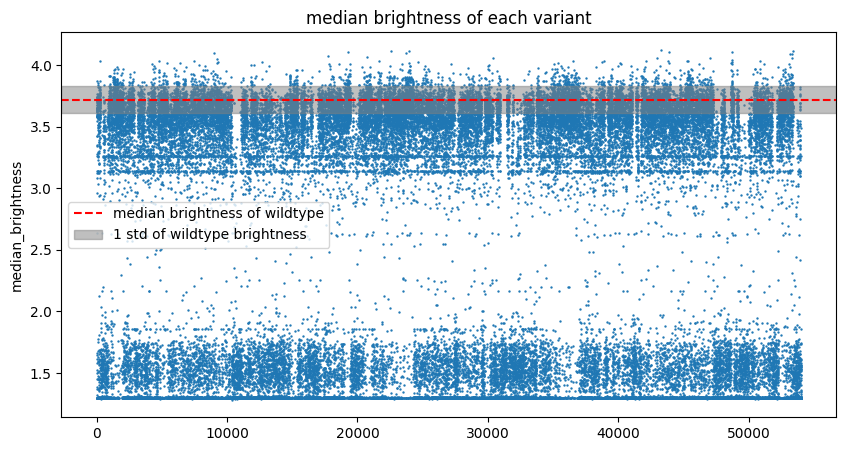

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.scatter(range(len(df)), df['medianBrightness'], s = 0.5)
plt.axhline(y=df['medianBrightness'].iloc[0], color='red', linestyle='--', label="median brightness of wildtype")
plt.axhspan(df['medianBrightness'].iloc[0] - df['std'].iloc[0], df['medianBrightness'].iloc[0] + df['std'].iloc[0], \
    color='gray', alpha=0.5, label="1 std of wildtype brightness")
plt.ylabel('median_brightness')
plt.title("median brightness of each variant")
plt.legend()
plt.show()


## load example

(1) PSI-blast(BlastP) without muscle between each round of BlastP

In [8]:
names, seqs = parse_fasta("/home/possu/jinho/allatom-design/ideas/GFP/fasta_data/psiblast_iter3_hits_ver1.fasta")

In [13]:
muscle_path = "/home/possu/jinho/allatom-design/muscle/bin/muscle"

In [17]:
!{muscle_path} -version

muscle 5.3.linux64 [cfc3eee]
Built Sep 14 2025 11:51:22



In [ ]:
# Run muscle
!{muscle_path} -align fasta_data/psiblast_iter3_hits_ver1.fasta \
    -output msa_results/psiblast_iter3_hits_ver1_raw.msa.fasta


muscle 5.3.linux64 [cfc3eee]  32.5Gb RAM, 24 cores
Built Sep 14 2025 11:51:22
(C) Copyright 2004-2021 Robert C. Edgar.
https://drive5.com

[super5 fasta_data/psiblast_iter3_hits_ver1.fasta]
Input: 1759 seqs, avg length 496, max 4161, min 35

00:00 7.0Mb   100.0% Derep 1759 uniques, 0 dupes
00:00 7.3Mb  CPU has 24 cores, running 24 threads                    
^C:30 55Mb      4.7% UCLUST 1759 seqs EE<0.01, 73 centroids, 9 members


In [ ]:
!muscle -version

In [ ]:
names,seqs = parse_fasta("09-30-2024_LanM-Ortholog-Data-for-ML.fasta")
msa_ori, msa = mk_msa(seqs)

print(msa_ori.shape)
print(msa.shape)

In [ ]:
# collecting some information about input msa
N = msa.shape[0] # number of sequences
L = msa.shape[1] # length of sequence
A = msa.shape[2] # number of states (or categories)


In [ ]:
class GREMLIN(torch.nn.Module):
  def __init__(self,L,A):
    super(GREMLIN, self).__init__()
    self.W0 = torch.nn.Parameter(torch.zeros(L*A,L*A), requires_grad=True)
    self.b0 = torch.nn.Parameter(torch.zeros(L*A), requires_grad=True)
    self.MASK = (1.0 -torch.eye(L*A))
  def forward(self,X):
    X = X.reshape(-1,L*A)
    W = (self.W0+self.W0.T)/2.0 * self.MASK

    MSA_pred = (X.mm(W)+self.b0).reshape(-1,L,A)
    loss = torch.sum(- MSA_Input * F.log_softmax(MSA_pred, -1))
    L2_w = torch.square(W).sum() * 0.01 * 0.5 *L*A
    L2_b = torch.square(self.b0).sum() * 0.01
    loss = loss + L2_w + L2_b
    return loss

In [ ]:
class Model(torch.nn.Module):
  def __init__(self,L,A):
    super(Model, self).__init__()
    self.GREMLIN_ = GREMLIN(L,A)

  def forward(self,X):
    loss = self.GREMLIN_(X)
    return loss

In [ ]:
#enviroment setting
device = torch.device("cuda:0") # Uncomment this to run on GPU
MSA_Input = torch.from_numpy(msa.astype(np.float32))


In [ ]:

model = Model(L,A)
learning_rate = 0.1*np.log(N)/L
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


for t in range(1000):

    loss = model(MSA_Input)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (t) % (int(100/10)) == 0:
      print(t, loss.item())



In [ ]:
w = model.GREMLIN_.W0.detach().numpy()
w = (w+w.T).reshape(L,A,L,A)

In [ ]:
torch.save(model.state_dict(), "gremlin_lanm_orthologs.pt")

## get contacts

In [ ]:
def get_mtx(W):
  # l2norm of 20x20 matrices (note: we ignore gaps)
  raw = np.sqrt(np.sum(np.square(W[:,:,:,:]),(1,3)))
  np.fill_diagonal(raw,0)
  # apc (average product correction)
  ap = np.sum(raw,0,keepdims=True)*np.sum(raw,1,keepdims=True)/np.sum(raw)
  apc = raw - ap
  np.fill_diagonal(apc,0)

  return(raw,apc)

In [ ]:
raw, apc = get_mtx(w)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(raw)
plt.grid(False)
plt.title("raw")
plt.subplot(1,2,2)
plt.imshow(apc)
plt.grid(False)
plt.title("apc")
plt.show()

## Visualizing couplings

In [ ]:
MRF_AA = "ARNDCQEGHILKMFPSTWYV-"
MRF_AA_IDX = {MRF_AA[i]: i for i in range(len(MRF_AA))}
MRF_IDX_AA = {i: MRF_AA[i].upper() for i in range(len(MRF_AA))}

hans_seq_aligned = ''.join([MRF_IDX_AA[i.item()] for i in torch.argmax(MSA_Input[22], dim=-1)])
mex_seq_aligned = ''.join([MRF_IDX_AA[i.item()] for i in torch.argmax(MSA_Input[421], dim=-1)])
mex_seq = 'MAPTTTTKVDIAAFDPDKDGTIDLKEALAAGSAAFDKLDPDKDGTLDAKELKGRVSEADLKKLDPDNDGTLDKKEYLAAVEAQFKAANPDNDGTIDARELASPAGSALVNLIR'


model = torch.load("gremlin_lanm_orthologs.pt")
w = model['GREMLIN_.W0'].detach().numpy()
w = (w+w.T).reshape(L,A,L,A)


def seq_to_aligned_idx(orig_seq: str, aligned_seq: str) -> dict[int, int]:
    orig_idx = 0
    mapping = {}
    for i, aa in enumerate(aligned_seq):
        if aa != '-':
            assert aa == orig_seq[orig_idx]
            mapping[orig_idx + 21] = i #! original sequence indexing starts from 21
            orig_idx += 1
    return mapping


In [ ]:
idx_convert = seq_to_aligned_idx(mex_seq, mex_seq_aligned)

In [ ]:
mex_seq_aligned

In [ ]:
mex_seq_aligned.find("ALAAG-----SAAFDK")

In [ ]:
mex_seq_aligned.find("YLAAVEAQFKAA")

In [ ]:
mex_seq_aligned.find("G--SALVNLIR")

In [ ]:
import plotly.express as px

colorscale = [
    [0, "red"],      # Red for the minimum value (-0.5)
    [0.5, "white"],  # White at 0
    [1, "blue"]      # Blue for the maximum value (0.5)
]

i_range = range(47, 58)
j_range = range(96, 108)
mags = []
#* sweep over contacting EF-hand linkers
for i in i_range:
  for j in j_range:
    ii = idx_convert[i]
    jj = idx_convert[j]
    # data = w[ii, :, jj, :]
    data = apc[ii, jj]
    max_magnitude = np.max([np.abs(np.max(data)), np.abs(np.min(data))])
    mags.append((f"{i} and {j}", max_magnitude))

mags = sorted(mags, key=lambda x : x[1], reverse=True)
for m in mags:
  print(m)


In [ ]:
i = 96
j = 130
ii = idx_convert[i]
jj = idx_convert[j]
title = f"Pairwise coevolution at {i} and {j}"

data = w[ii, :, jj, :]

z_cutoff = np.max([np.abs(np.max(data)), np.abs(np.min(data))])
tick_labels = list(MRF_AA)
fig = px.imshow(data, x=tick_labels, y=tick_labels, color_continuous_scale=colorscale, zmin=-z_cutoff, zmax=z_cutoff, title=title)
fig.show()

## Likelihoods

In [ ]:
from functools import partial


def gremlin_prior_(seq, h=None, J=None):
    """
    seq: aligned sequence string
    h: fields vector (L*q)
    J: couplings matrix (L*q, L*q)
    """
    s = torch.from_numpy(np.array([MRF_AA_IDX[aa] for aa in seq])).to(h)
    q = len(MRF_AA)
    L = len(s)
    if h is None:
        h = torch.randn(L*q)
    if J is None:
        J = torch.randn(L*q, L*q)
    # compute indicies of s by adding to it [0, 0, 0, ... 21, 21, 21 ...]
    s_idx = (s + torch.linspace(0, q*(L-1), L)).to(h).type(torch.LongTensor)
    sum_h = torch.sum(h[s_idx])
    j_idx = torch.meshgrid(s_idx, s_idx)
    sum_J = torch.sum(J[j_idx])
    return (sum_h + sum_J).item()


gremlin_prior = partial(gremlin_prior_, h=model.GREMLIN_.b0.detach(), J=model.GREMLIN_.W0.detach())

In [ ]:
gremlin_prior(mex_seq_aligned)

In [ ]:
gremlin_prior('W'*len(mex_seq_aligned))

In [ ]:
gremlin_prior(hans_seq_aligned)


In [ ]:
linreg_greedy_seq = "----------------------------IS------PLDDIR-----SLNSSHQSHLSISHAKGLT-----DKVYGTFEISHWNSVKVKRDWTVFIDIAVKQFRRQDNKVRDKTG---ITLRRSLQYTQG-QPKMKQNKLVNPFMFAHY-REPVVRITK-----------------------------"

gremlin_prior(linreg_greedy_seq)

In [ ]:
linreg_gradient_seq = "AEQIHWVMHYEMLQYYKWIYAKFWDPERMHWRWLALKNQPTFGDGRRLMKQDTIPDAGVTHRFWQLSRVLLAFNFLGNQIPFFNVMADPGGHINDEYVEEFIPHIAHNWLTMLDPFWKKGSRVTWTFGVNTWKVAHSMRNIGSAIFAMVNFDPWKYNMENQVPYIKTKNLFEQIQMNFSAVNSSHRWK"

gremlin_prior(linreg_gradient_seq)

In [ ]:
all_priors = []

for i in range(MSA_Input.shape[0]):
    curr_seq = ''.join([MRF_IDX_AA[i.item()] for i in torch.argmax(MSA_Input[i], dim=-1)])

    all_priors.append(gremlin_prior(curr_seq))


In [ ]:
import seaborn as sns

sns.kdeplot(x=all_priors, fill=True)

plt.show()